# Non-Linear Digital Moog Ladder Filter

Implementació basada en:
> Huovilainen, A. (2004). *Non-Linear Digital Implementation of the Moog Ladder Filter*. DAFx-04, Naples.

### Característiques incloses
- Model no lineal amb `tanh` embegut en cada etapa
- Sobremostreig (2x per defecte) per evitar aliasing
- Compensació amb mitja unitat de retard en el camí de feedback
- Taula de tuning per corregir l'error de freqüència residual
- 5 avaluacions de `tanh` per mostra

In [1]:
import glob, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from scipy.signal import freqz
from scipy.io import wavfile
from IPython.display import Audio, display
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 4)

## 1. Implementació del filtre

In [2]:
class MoogLadderFilter:
    """
    Implementació no lineal del filtre Moog Ladder (Huovilainen 2004).

    Paràmetres
    ----------
    sample_rate : int
        Freqüpencia de mostreig de l'àudio d'entrada (Hz).
    cutoff : float
        Freqüència de tall inicial (Hz).
    resonance : float
        Quantitat de ressonància [0, 1]. En 1.0 el filtre oscil·la.
    oversample : int
        Factor de sobremostreig (2 per defecte).
    half_delay : bool
        Si true, aplica la compensació de mitja unitat (promig de dues mostres)
        en el camí de feedback per alinear la ressonància amb la freqüència de tall.
    """

    def __init__(self, sample_rate=44100, cutoff=1000.0, resonance=0.5,
                 oversample=2, half_delay=True):
        self.sample_rate = sample_rate
        self.oversample = oversample
        self.half_delay = half_delay
        self.fs_over = sample_rate * oversample   # sample rate intern

        # Estats interns de les 4 etapes
        self.y = np.zeros(4)   # sortides de cada etapa
        self.w = np.zeros(4)   # tanh(y / (2*Vt)) en cache
        self._last_out = 0.0   # per al compensador de mitja unitat

        self.set_cutoff(cutoff)
        self.set_resonance(resonance)

    # ------------------------------------------------------------------
    # Paràmetres públics
    # ------------------------------------------------------------------

    def set_cutoff(self, cutoff_hz):
        """Calcula el coeficient g amb scaled impulse invariant transform
        (ec. 21 del paper) y l'emmagatzema"""
        self.cutoff = np.clip(cutoff_hz, 1.0, self.fs_over * 0.49) # Entre 1.0 Hz i la freq. de Nyquist (<fs/2)
        self.g = 1.0 - np.exp(-2.0 * np.pi * self.cutoff / self.fs_over)

    def set_resonance(self, resonance):
        """Ressonància en [0, 1]."""
        self.resonance = np.clip(resonance, 0.0, 2.0)

    # ------------------------------------------------------------------
    # Nucli del filtre: processa una mostra (fs_over mostres per segon)
    # ------------------------------------------------------------------

    def _process_sample(self, x):
        """
        Processa una mostra al sample rate intern (oversampled).
        Implementa les equacions (13)-(17) i (22) del paper.

        La no linealitat tanh és present a:
          - L'entrada de la primera etapa (input tanh)
          - La realimentació (feedback tanh)
          - Les W_i que alimenten les etapes 2, 3 y 4

        Compensació de mig retard: mitjana entre la sortida actual
        i l'anterior abans d'injectar-la al feedback (ec. 23).
        """
        g = self.g
        r = self.resonance
        y = self.y
        w = self.w
        # Valor físic real: Vt ≈ 0.026 (26 mV)
        # Amb senyals normalitzades en [-1, 1], Vt = 0.5 és una
        # convenció habitual que situa la saturació en ±1
        self.Vt = 0.5

        # Sortida del filtre (nivell 4)
        out = y[3]

        # Compensació de mig retard en el feedback
        if self.half_delay:
            fb = 0.5 * (out + self._last_out)
        else:
            fb = out
        self._last_out = out

        # Etapa 1 (ec. 22): entrada amb feedback
        # W_{in} = tanh(x / 2Vt)  i  W_d = tanh(y_d / 2Vt)
        inp_tanh = np.tanh((x - 4.0 * r * fb) / (2 * self.Vt))   # tanh del node d'entrada
        y[0] = y[0] + 2 * self.Vt * g * (inp_tanh - w[0])
        w[0] = np.tanh(y[0] / (2 * self.Vt))

        # Etapes 2, 3, 4 (ecs. 14–16)
        for k in range(1, 4):
            y[k] = y[k] + g * (w[k-1] - w[k])
            w[k] = np.tanh(y[k])

        return y[3]

    # ------------------------------------------------------------------
    # API principal: processa un bloc d'àudio
    # ------------------------------------------------------------------

    def process(self, x_in):
        """
        Processa un array d'àudio a `sample_rate`.

        Internament fa sobremostreig simple (repetició de mostres),
        aplica el filtre al sample rate intern i fa submostreig
        prenent una mostra de cada `oversample` (decimació simple),
        Per àudio d'alta qualitat utilitzem scipy.signal.resample_poly.

        Retorna un array de la mateixa mida que x_in.
        """
        n = len(x_in)
        os = self.oversample

        # Sobremostreig: repetir cada mostra `os` vegades
        x_up = np.repeat(x_in, os)

        # Processar mostra per mostra
        y_up = np.empty(len(x_up))
        for i, s in enumerate(x_up):
            y_up[i] = self._process_sample(s)

        # Submostreig: prendre 1 de cada `os` mostres
        return y_up[os-1::os]

    def reset(self):
        """Reseteja l'estat intern."""
        self.y[:] = 0.0
        self.w[:] = 0.0
        self._last_out = 0.0

## 2. Generadors de senyal de prova

In [3]:
def sine(freq=440.0, duration=1.0, amplitude=0.5, sr=44100):
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    return np.sin(2 * np.pi * freq * t) * amplitude

def sawtooth(freq=440.0, duration=1.0, amplitude=0.5, sr=44100):
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    return (2 * (t * freq - np.floor(t * freq + 0.5))) * amplitude

def square(freq=440.0, duration=1.0, amplitude=0.5, sr=44100):
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    return np.sign(np.sin(2 * np.pi * freq * t)) * amplitude

def white_noise(duration=1.0, amplitude=0.5, sr=44100, seed=42):
    rng = np.random.default_rng(seed)
    return rng.standard_normal(int(sr * duration)) * amplitude

def impulse(duration=0.5, amplitude=1.0, sr=44100):
    """Impuls unitari, útil per veure la resposta a l'impuls del filtre."""
    n = int(sr * duration)
    x = np.zeros(n)
    x[0] = amplitude
    return x

GENERATORS = {
    'sine':    sine,
    'sawtooth': sawtooth,
    'square':  square,
    'noise':   white_noise,
    'impulse': impulse,
}

## 3. Utilitats d'anàlisi i plot

In [4]:
def compute_spectrum(signal, sr, n_fft=None):
    """Retorna (freqs_hz, magnitud_dB) de l'espectre."""
    n = len(signal)
    if n_fft is None:
        n_fft = next_power_of_2(n)
    window = np.hanning(n)
    X = np.fft.rfft(signal * window, n=n_fft)
    freqs = np.fft.rfftfreq(n_fft, d=1.0/sr)
    mag = np.abs(X) / (n / 2)
    mag_db = 20 * np.log10(np.maximum(mag, 1e-12))
    return freqs, mag_db

def next_power_of_2(n):
    p = 1
    while p < n:
        p = p * 2
    return p


def plot_filter_response(filt, sr=44100, amplitude=0.01, title=None):
    """
    Calcula la resposta en freqüpencia del filtre utilitzant soroll blanc
    de baixa amplitud (règim lineal) i la representa en dB.
    """
    filt.reset()
    x = white_noise(duration=2.0, amplitude=amplitude, sr=sr)
    y = filt.process(x)

    freqs_x, mag_x = compute_spectrum(x, sr)
    freqs_y, mag_y = compute_spectrum(y, sr)

    response_db = mag_y - mag_x  # H(f) en dB

    plt.figure(figsize=(12, 4))
    plt.semilogx(freqs_y[1:], response_db[1:], lw=1.5)
    plt.axvline(filt.cutoff, color='r', linestyle='--', alpha=0.7,
                label=f'Cutoff = {filt.cutoff:.0f} Hz')
    plt.xlabel('Freqüència (Hz)')
    plt.ylabel('Magnitud (dB)')
    plt.title(title or f'Respuosta en freqüència — cutoff={filt.cutoff:.0f} Hz, resonance={filt.resonance:.2f}')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)
    plt.xlim([20, sr / 2])
    plt.tight_layout()
    plt.show()


def plot_io_spectrum(x, y, sr=44100, title=''):
    """Compara els espectres d'entrada i sortida."""
    freqs_x, mag_x = compute_spectrum(x, sr)
    freqs_y, mag_y = compute_spectrum(y, sr)

    plt.figure(figsize=(12, 4))
    plt.semilogx(freqs_x[1:], mag_x[1:], label='Entrada', alpha=0.7, lw=1)
    plt.semilogx(freqs_y[1:], mag_y[1:], label='Sortida (filtrada)', lw=1.5)
    plt.xlabel('Freqüència (Hz)')
    plt.ylabel('Magnitud (dB)')
    plt.title(title or 'Espectre entrada vs sortida')
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)
    plt.xlim([20, sr / 2])
    plt.tight_layout()
    plt.show()


def plot_waveform(x, y, sr=44100, duration_ms=50, title=''):
    """Mostra els primers `duration_ms` ms de les formes d'ona."""
    n = int(sr * duration_ms / 1000)
    t = np.arange(n) / sr * 1000  # ms

    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
    axes[0].plot(t, x[:n], lw=0.8)
    axes[0].set_ylabel('Entrada')
    axes[0].grid(alpha=0.3)
    axes[1].plot(t, y[:n], lw=0.8, color='C1')
    axes[1].set_ylabel('Sortida')
    axes[1].set_xlabel('Temps (ms)')
    axes[1].grid(alpha=0.3)
    fig.suptitle(title or "Formes d'ona")
    plt.tight_layout()
    plt.show()

def save_wav(filename, signal, sr=44100, normalize=False):
    """Guarda un array float com arxiu WAV float32."""
    s = signal.astype(np.float32)
    if normalize:
        peak = np.max(np.abs(s))
        if peak > 0:
            s = s / peak * 0.9

    wavfile.write(filename, sr, s)
    print(f'Guardat: {filename}  (float32)')

def play_audio(signal, sr=44100, normalize=True):
    s = signal.copy()
    if normalize:
        peak = np.max(np.abs(s))
        if peak > 0:
            s = s / peak * 0.9
    display(Audio(s, rate=sr))

## 4. Resposta en freqüència amb diferents cutoffs i ressonàncies

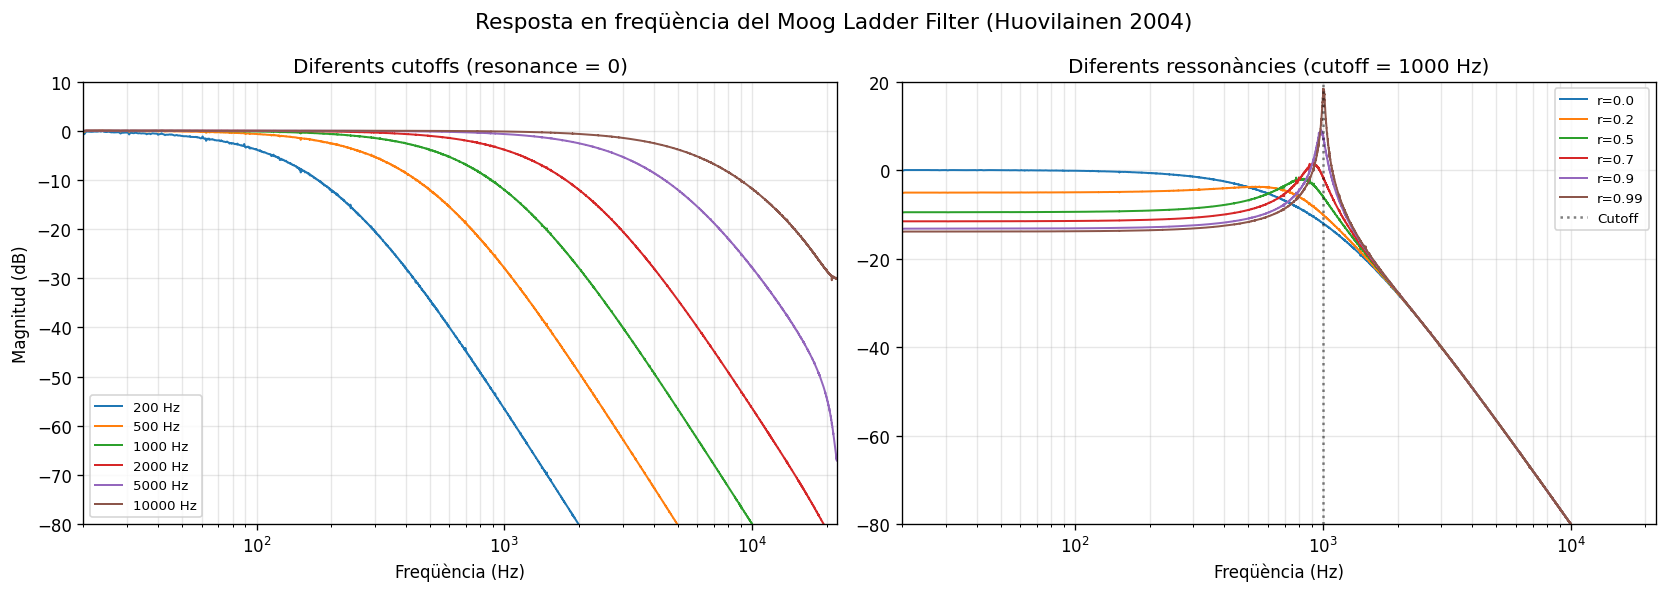

In [68]:
SR = 44100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Esquerra: diferents cutoffs, ressonància fixa ---
ax = axes[0]
for cutoff in [200, 500, 1000, 2000, 5000, 10000]:
    filt = MoogLadderFilter(SR, cutoff=cutoff, resonance=0.0, oversample=2)
    x = white_noise(duration=2.0, amplitude=0.01, sr=SR)
    filt.reset()
    y = filt.process(x)
    freqs_x, mag_x = compute_spectrum(x, SR)
    freqs_y, mag_y = compute_spectrum(y, SR)
    resp = mag_y - mag_x
    ax.semilogx(freqs_y[1:], resp[1:], label=f'{cutoff} Hz', lw=1.2)
ax.set_title('Diferents cutoffs (resonance = 0)')
ax.set_xlabel('Freqüència (Hz)')
ax.set_ylabel('Magnitud (dB)')
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([20, SR/2])
ax.set_ylim([-80, 10])

# --- Dreta: diferents ressonàncies, cutoff fix ---
ax = axes[1]
cutoff = 1000
for res in [0.0, 0.2, 0.5, 0.7, 0.9, 0.99]:
    filt = MoogLadderFilter(SR, cutoff=cutoff, resonance=res, oversample=2)
    x = white_noise(duration=2.0, amplitude=0.01, sr=SR)
    filt.reset()
    y = filt.process(x)
    freqs_x, mag_x = compute_spectrum(x, SR)
    freqs_y, mag_y = compute_spectrum(y, SR)
    resp = mag_y - mag_x
    ax.semilogx(freqs_y[1:], resp[1:], label=f'r={res}', lw=1.2)
ax.axvline(cutoff, color='k', linestyle=':', alpha=0.5, label=f'Cutoff')
ax.set_title(f'Diferents ressonàncies (cutoff = {cutoff} Hz)')
ax.set_xlabel('Freqüència (Hz)')
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.3)
ax.set_xlim([20, SR/2])
ax.set_ylim([-80, 20])

plt.suptitle('Resposta en freqüència del Moog Ladder Filter (Huovilainen 2004)', fontsize=13)
plt.tight_layout()
plt.show()

### Mesures amb sweep: importem el senyal i exportem els resultats

In [69]:
# --- Importar el sweep de REW ---
sr, sweep_raw = wavfile.read("512kMeasSweep_20_to_20000_-20_dBFS_44k_Float_ref.wav")

# Normalitzar a float32 [-1, 1]
if sweep_raw.dtype == np.int16:
    sweep = sweep_raw.astype(np.float32) / 32768.0
elif sweep_raw.dtype == np.int32:
    sweep = sweep_raw.astype(np.float32) / 2147483648.0
else:
    sweep = sweep_raw.astype(np.float32)

# Si és estèreo, agafar només el canal esquerre
if sweep.ndim == 2:
    sweep = sweep[:, 0]

#### IR with different cutoff frequencies

In [ ]:
# --- Configuracions CUTOFF diferent ---
configs = [
    {"cutoff": 200,   "resonance": 0.0},
    {"cutoff": 500,   "resonance": 0.0},
    {"cutoff": 1000,  "resonance": 0.0},
    {"cutoff": 2000,  "resonance": 0.0},
    {"cutoff": 5000,  "resonance": 0.0},
    {"cutoff": 10000,  "resonance": 0.0}
]

# --- Processar i exportar ---
for cfg in configs:
    filt = MoogLadderFilter(sr, cutoff=cfg["cutoff"],
                            resonance=cfg["resonance"], oversample=4)
    filt.reset()
    y = filt.process(sweep)

    filename = f"filter_c{int(cfg['cutoff'])}_r{int(cfg['resonance']*100):02d}.wav"
    ##save_wav(filename, y, sr=sr, normalize=False)  # normalize=False és important!

#### IR with different resonance values

In [ ]:
# --- Configuracions RESONANCE diferent ---
configs = [   
    {"cutoff": 1000,  "resonance": 0.0},
    {"cutoff": 1000,  "resonance": 0.2},
    {"cutoff": 1000,  "resonance": 0.5},
    {"cutoff": 1000,  "resonance": 0.7},
    {"cutoff": 1000,  "resonance": 0.9},
    {"cutoff": 1000,  "resonance": 0.99}
]

# --- Processar i exportar ---
for cfg in configs:
    filt = MoogLadderFilter(sr, cutoff=cfg["cutoff"],
                            resonance=cfg["resonance"], oversample=2)
    filt.reset()
    y = filt.process(sweep)

    filename = f"filter_c{int(cfg['cutoff'])}_r{int(cfg['resonance']*100):02d}.wav"
    ##save_wav(filename, y, sr=sr, normalize=False)  # normalize=False és important!

Guardat: filter_c1000_r200.wav  (float32)


In [ ]:
# Anàlisi des del Notebook (sense deconvolució de REW) - Finalment no cal, tenim tot l'anàlisi amb REW
"""
def compute_H(x, y):
    H(f) = Y(f) / X(f). Retorna freqs, SPL (dB), fase unwrapped (graus).
    n_fft = 1
    while n_fft < max(len(x), len(y)):
        n_fft <<= 1
    X = np.fft.rfft(x, n=n_fft)
    Y = np.fft.rfft(y, n=n_fft)
    H = Y / (X + 1e-12)
    freqs = np.fft.rfftfreq(n_fft, d=1.0 / SR)
    spl   = 20 * np.log10(np.abs(H) + 1e-12)
    phase = np.unwrap(np.angle(H)) * 180.0 / np.pi
    return freqs, spl, phase

# ── Paràmetres ────────────────────────────────────────────────────────
SR = 44100
FOLDER = "Filter recordings"
SWEEP_REF = "512kMeasSweep_20_to_20000_-20_dBFS_44k_Float_ref.wav"

configs = [
    {"cutoff": 1000, "resonance": 0.00},
    {"cutoff": 1000, "resonance": 0.20},
    {"cutoff": 1000, "resonance": 0.50},
    {"cutoff": 1000, "resonance": 0.70},
    {"cutoff": 1000, "resonance": 0.90},
    {"cutoff": 1000, "resonance": 0.99},
]

def wav_filename(cfg):
    return f"{FOLDER}/filter_c{int(cfg['cutoff'])}_r{int(cfg['resonance']*100):02d}.wav"

# ── Càrrega sweep de referència ───────────────────────────────────────
sr_ref, raw_ref = wavfile.read(SWEEP_REF)
x = raw_ref.astype(np.float32)
if x.ndim == 2:
    x = x[:, 0]

# ── Plot ──────────────────────────────────────────────────────────────
fig, (ax_spl, ax_phase) = plt.subplots(
    2, 1, figsize=(14, 9), sharex=True,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.08}
)
fig.patch.set_facecolor('#ffffff')
for ax in (ax_spl, ax_phase):
    ax.set_facecolor('#ffffff')

colors = ['#2393ff', '#ff6d3c', '#009200', '#ce0a0a', '#9797ff', '#962d01']

for i, cfg in enumerate(configs):
    fname = wav_filename(cfg)
    if not os.path.exists(fname):
        print(f"⚠️  No trobat: {fname}")
        continue

    _, raw_y = wavfile.read(fname)
    y = raw_y.astype(np.float32)
    if y.ndim == 2:
        y = y[:, 0]

    n = min(len(x), len(y))
    freqs, spl, phase = compute_H(x[:n], y[:n])

    mask = (freqs >= 20) & (freqs <= 20000)
    f, s, p = freqs[mask], spl[mask], phase[mask]

    label = f"res = {cfg['resonance']:.2f}"
    ax_spl.semilogx(f, s, color=colors[i], linewidth=1.6, label=label)

    p_wrapped = ((p + 180) % 360) - 180
    ax_phase.semilogx(f, p_wrapped, color=colors[i], linewidth=1.2, label=label)

# ── Estètica SPL ──────────────────────────────────────────────────────
ax_spl.set_xlim(20, 20000)
ax_spl.set_ylim(-80, 10)
ax_spl.set_ylabel("dB (relative)", color='#222222', fontsize=11)
ax_spl.axhline(-3, color='#aaaaaa', linewidth=0.8, linestyle=':')
ax_spl.axvline(1000, color='#aaaaaa', linewidth=0.8, linestyle=':')

legend = ax_spl.legend(loc='lower left', framealpha=0.7,
                       labelcolor='black', fontsize=10)
legend.get_frame().set_facecolor('#f5f5f5')
legend.get_frame().set_edgecolor('#cccccc')

ax_spl.set_title(
    "Filter - cutoff 1000 Hz, oversample 2x\n"
    "Direct analysis from notebook (without REW deconvolution)",
    color='#222222', fontsize=12, pad=10
)

# ── Estètica Fase ─────────────────────────────────────────────────────
ax_phase.set_xlim(20, 20000)
ax_phase.set_ylim(-180, 180)
ax_phase.set_ylabel("Phase (degrees)", color='#222222', fontsize=11)
ax_phase.set_xlabel("Frequency (Hz)", color='#222222', fontsize=11)
ax_phase.axhline(0,    color='#aaaaaa', linewidth=0.8, linestyle=':')
ax_phase.axhline(-180, color='#cccccc', linewidth=0.8, linestyle=':')
ax_phase.axvline(1000, color='#aaaaaa', linewidth=0.8, linestyle=':')

# ── Comú ──────────────────────────────────────────────────────────────
for ax in (ax_spl, ax_phase):
    ax.tick_params(colors='#333333', which='both')
    for spine in ax.spines.values():
        spine.set_color('#c2c2c2')
    ax.grid(True, which='both', color='#c2c2c2', linewidth=0.6)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(
        lambda v, _: f"{int(v/1000)}k" if v >= 1000 else str(int(v))
    ))
    ax.xaxis.set_major_locator(ticker.LogLocator(base=10, subs=[1,2,3,4,6,8], numticks=100))
    ax.xaxis.set_minor_locator(ticker.LogLocator(base=10, subs=[5,7,9], numticks=100))
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())

plt.tight_layout()
plt.savefig("filter_analysis_resonances.png", dpi=150, bbox_inches='tight',
            facecolor='#ffffff')
plt.show()
print("Guardat: filter_analysis_resonances.png")
"""

'\ndef compute_H(x, y):\n    H(f) = Y(f) / X(f). Retorna freqs, SPL (dB), fase unwrapped (graus).\n    n_fft = 1\n    while n_fft < max(len(x), len(y)):\n        n_fft <<= 1\n    X = np.fft.rfft(x, n=n_fft)\n    Y = np.fft.rfft(y, n=n_fft)\n    H = Y / (X + 1e-12)\n    freqs = np.fft.rfftfreq(n_fft, d=1.0 / SR)\n    spl   = 20 * np.log10(np.abs(H) + 1e-12)\n    phase = np.unwrap(np.angle(H)) * 180.0 / np.pi\n    return freqs, spl, phase\n\n# ── Paràmetres ────────────────────────────────────────────────────────\nSR = 44100\nFOLDER = "Filter recordings"\nSWEEP_REF = "512kMeasSweep_20_to_20000_-20_dBFS_44k_Float_ref.wav"\n\nconfigs = [\n    {"cutoff": 1000, "resonance": 0.00},\n    {"cutoff": 1000, "resonance": 0.20},\n    {"cutoff": 1000, "resonance": 0.50},\n    {"cutoff": 1000, "resonance": 0.70},\n    {"cutoff": 1000, "resonance": 0.90},\n    {"cutoff": 1000, "resonance": 0.99},\n]\n\ndef wav_filename(cfg):\n    return f"{FOLDER}/filter_c{int(cfg[\'cutoff\'])}_r{int(cfg[\'resonance\'

## 5. Comparació: amb i sense retard de mitja unitat

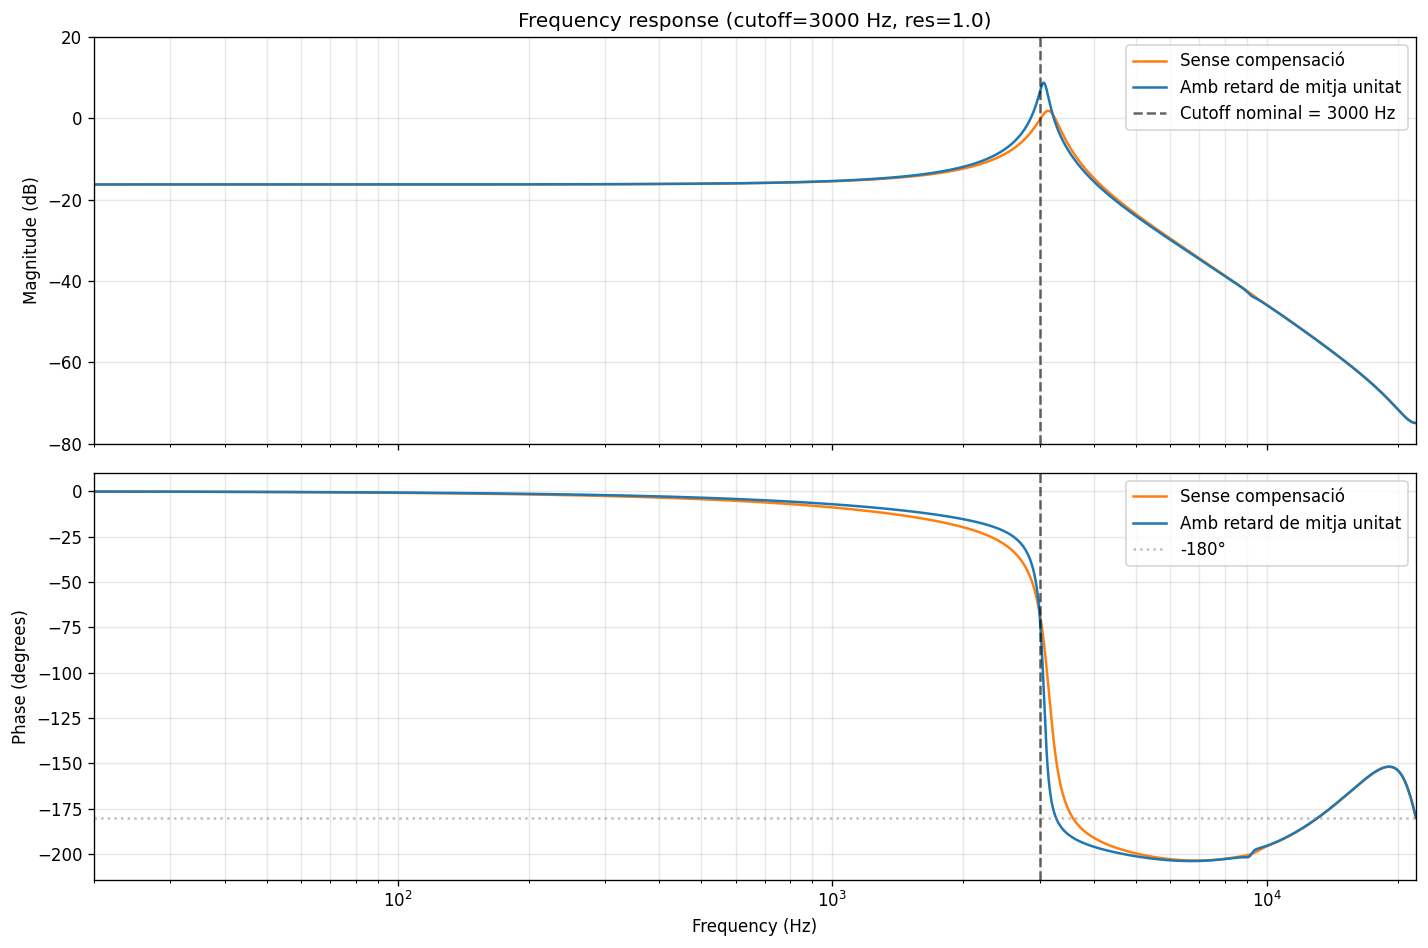

In [84]:
cutoff = 3000
res    = 1.0

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for half_delay, label, color in [(False, 'Sense compensació', 'C1'),
                                  (True,  'Amb retard de mitja unitat', 'C0')]:
    # Resposta a l'impuls: entrada és directament un impuls unitari
    x_imp = impulse(duration=0.5, amplitude=1.0, sr=SR)
    filt = MoogLadderFilter(SR, cutoff=cutoff, resonance=res,
                            oversample=2, half_delay=half_delay)
    filt.reset()
    h = filt.process(x_imp)   # h és la resposta a l'impuls

    n_fft = next_power_of_2(len(h))
    H = np.fft.rfft(h, n=n_fft)
    freqs = np.fft.rfftfreq(n_fft, d=1.0/SR)

    mag_db = 20 * np.log10(np.abs(H) + 1e-12)
    phase  = np.unwrap(np.angle(H)) * (180 / np.pi)

    axes[0].semilogx(freqs[1:], mag_db[1:], label=label, color=color, lw=1.5)
    axes[1].semilogx(freqs[1:], phase[1:],  label=label, color=color, lw=1.5)

axes[0].axvline(cutoff, color='k', linestyle='--', alpha=0.6,
                label=f'Cutoff nominal = {cutoff} Hz')
axes[0].set_ylabel('Magnitude (dB)')
axes[0].set_title(f'Frequency response (cutoff={cutoff} Hz, res={res})')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)
axes[0].set_ylim([-80, 20])

axes[1].axvline(cutoff, color='k', linestyle='--', alpha=0.6)
axes[1].axhline(-180, color='gray', linestyle=':', alpha=0.5, label='-180°')
axes[1].set_ylabel('Phase (degrees)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

axes[0].set_xlim([20, SR/2])
plt.tight_layout()
plt.show()

### Mesures amb sweep: importem el senyal i exportem els resultats
#### IR with and without time delay compensation

In [86]:
# --- Configuracions RESONANCE diferent ---
configs = [   
    {"cutoff": 1000,  "resonance": 0.0,  "delay": False},
    {"cutoff": 1000,  "resonance": 0.2,  "delay": False},
    {"cutoff": 1000,  "resonance": 0.5,  "delay": False},
    {"cutoff": 1000,  "resonance": 0.7,  "delay": False},
    {"cutoff": 1000,  "resonance": 0.9,  "delay": False},
    {"cutoff": 1000,  "resonance": 0.99, "delay": False}
]

# --- Processar i exportar ---
for cfg in configs:
    filt = MoogLadderFilter(sr, cutoff=cfg["cutoff"],
                            resonance=cfg["resonance"], oversample=2, half_delay=cfg["delay"])
    filt.reset()
    y = filt.process(sweep)

    filename = f"filter_c{int(cfg['cutoff'])}_r{int(cfg['resonance']*100):02d}_notdelayed.wav"
    save_wav(filename, y, sr=sr, normalize=False)  # normalize=False és important!

Guardat: filter_c1000_r00_notdelayed.wav  (float32)
Guardat: filter_c1000_r20_notdelayed.wav  (float32)
Guardat: filter_c1000_r50_notdelayed.wav  (float32)
Guardat: filter_c1000_r70_notdelayed.wav  (float32)
Guardat: filter_c1000_r90_notdelayed.wav  (float32)
Guardat: filter_c1000_r99_notdelayed.wav  (float32)


## 6. Efecte de la no linealitat: amplitud d'entrada vs distorsió

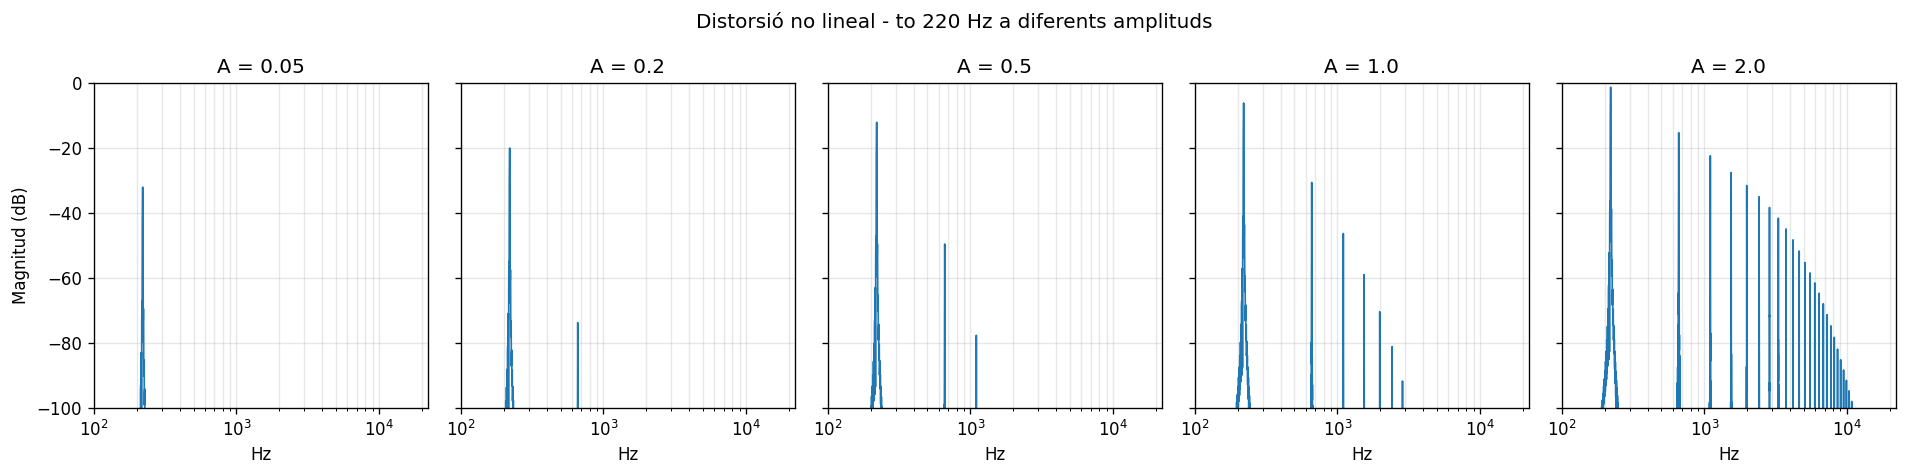

In [13]:
"""
Amb més amplitud d'entrada, el tanh satura i es generen harmònics.
Aquí ho visualitzem comparant l'espectre de sortida per a diferents
amplituds d'un to pur.
"""
SR = 44100
FREQ   = 220    # Hz - to de prova
CUTOFF_NL = 5000  # Hz - cutoff alt per veure els harmònics generats

amplitudes = [0.05, 0.2, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, len(amplitudes), figsize=(16, 4), sharey=True)

for ax, amp in zip(axes, amplitudes):
    x = sine(FREQ, duration=1.0, amplitude=amp, sr=SR)
    filt = MoogLadderFilter(SR, cutoff=CUTOFF_NL, resonance=0.0, oversample=2)
    filt.reset()
    y = filt.process(x)
    freqs_y, mag_y = compute_spectrum(y, SR)
    ax.semilogx(freqs_y[1:], mag_y[1:], lw=1)
    ax.set_title(f'A = {amp}')
    ax.set_xlabel('Hz')
    ax.set_xlim([100, SR/2])
    ax.set_ylim([-100, 0])
    ax.grid(True, which='both', alpha=0.3)

axes[0].set_ylabel('Magnitud (dB)')
fig.suptitle(f'Distorsió no lineal - to {FREQ} Hz a diferents amplituds', fontsize=12)
plt.tight_layout()
plt.show()

### Mesures amb sweep: importem el senyal i exportem els resultats

#### To de 440 Hz amb REW

In [ ]:
# --- Configuracions RESONANCE diferent ---
configs = [   
    {"cutoff": 5000,  "resonance": 0.0,  "amplitude": -30},
    {"cutoff": 5000,  "resonance": 0.0,  "amplitude": -20},
    {"cutoff": 5000,  "resonance": 0.0,  "amplitude": -12},
    {"cutoff": 5000,  "resonance": 0.0,  "amplitude": -6},
    {"cutoff": 5000,  "resonance": 0.0,  "amplitude": 0}
]

# --- Processar i exportar ---
for cfg in configs:
    sr, tone = wavfile.read(f"Sine_220_{int(cfg['amplitude'])}_dBFS_44k_Float.wav")
    filt = MoogLadderFilter(sr, cutoff=cfg["cutoff"],
                            resonance=cfg["resonance"], oversample=2)
    filt.reset()
    y = filt.process(tone)

    filename = f"filter_c{int(cfg['cutoff'])}_r{int(cfg['resonance']*100):02d}_{int(cfg['amplitude'])}_dBFS.wav"
    save_wav(filename, y, sr=sr, normalize=False)  # normalize=False és important!

Guardat: filter_c5000_r00_-30_dBFS.wav  (float32)
Guardat: filter_c5000_r00_-20_dBFS.wav  (float32)
Guardat: filter_c5000_r00_-12_dBFS.wav  (float32)
Guardat: filter_c5000_r00_-6_dBFS.wav  (float32)
Guardat: filter_c5000_r00_0_dBFS.wav  (float32)


In [21]:
# ── THD per amplitud — taula completa ─────────────────────────────────
FUNDAMENTAL = 220.0
N_HARMONICS = 8
CUTOFF_NL   = 5000
RES_NL      = 0.0

configs_thd = [
    {"amplitude_dbfs": -30},
    {"amplitude_dbfs": -20},
    {"amplitude_dbfs": -12},
    {"amplitude_dbfs":  -6},
    {"amplitude_dbfs":   0},
]

def thd_percent(y, sr, fundamental=220.0, n_harmonics=8):
    """
    Retorna:
      - thd_total  : THD total en % respecte el fonamental
      - hd_percent : dict {n: %} per a cada harmònic H2..Hn
    """
    n_fft = 1
    while n_fft < len(y): n_fft <<= 1
    Y     = np.abs(np.fft.rfft(y, n=n_fft))
    freqs = np.fft.rfftfreq(n_fft, d=1.0/sr)

    def peak_linear(f):
        idx    = np.argmin(np.abs(freqs - f))
        window = Y[max(0, idx-5):idx+6]
        return np.max(window)

    V1 = peak_linear(fundamental)   # amplitud lineal del fonamental

    hd_percent = {}
    sum_sq = 0.0
    for n in range(2, n_harmonics + 1):
        f = fundamental * n
        if f < sr / 2:
            Vn = peak_linear(f)
            pct = (Vn / V1) * 100.0
            hd_percent[n] = pct
            sum_sq += Vn**2

    thd_total = (np.sqrt(sum_sq) / V1) * 100.0
    return thd_total, hd_percent


rows = []
for cfg in configs_thd:
    amp_dbfs = cfg["amplitude_dbfs"]

    # Carregar el WAV filtrat ja existent
    fname = (f"Filter Recordings/"
             f"filter_c{CUTOFF_NL}"
             f"_r{int(RES_NL*100):02d}"
             f"_{amp_dbfs}_dBFS.wav")
    sr, y = wavfile.read(fname)

    thd_total, hd_pct = thd_percent(y, sr, FUNDAMENTAL, N_HARMONICS)

    row = {"Amplitud (dBFS)": amp_dbfs, "THD (%)": round(thd_total, 4)}
    for n in range(2, N_HARMONICS + 1):
        row[f"HD{n} (%)"] = round(hd_pct.get(n, 0.0), 4)
    rows.append(row)

df = pd.DataFrame(rows).set_index("Amplitud (dBFS)")
display(df)

,THD (%),HD2 (%),HD3 (%),HD4 (%),HD5 (%),HD6 (%),HD7 (%),HD8 (%)
Amplitud (dBFS),,,,,,,,
-30,0.1051,0.0946,0.0369,0.0201,0.0129,0.0089,0.0068,0.0051
-20,0.1125,0.0944,0.0550,0.0202,0.0129,0.0089,0.0066,0.0049
-12,0.3370,0.0944,0.3223,0.0202,0.0150,0.0089,0.0065,0.0050
-6,1.3269,0.0941,1.3224,0.0206,0.0502,0.0090,0.0067,0.0050
0,5.9618,0.0922,5.8849,0.0252,0.9278,0.0091,0.2026,0.0049


## 7. Auto-oscil·lació (resonance ≈ 1)

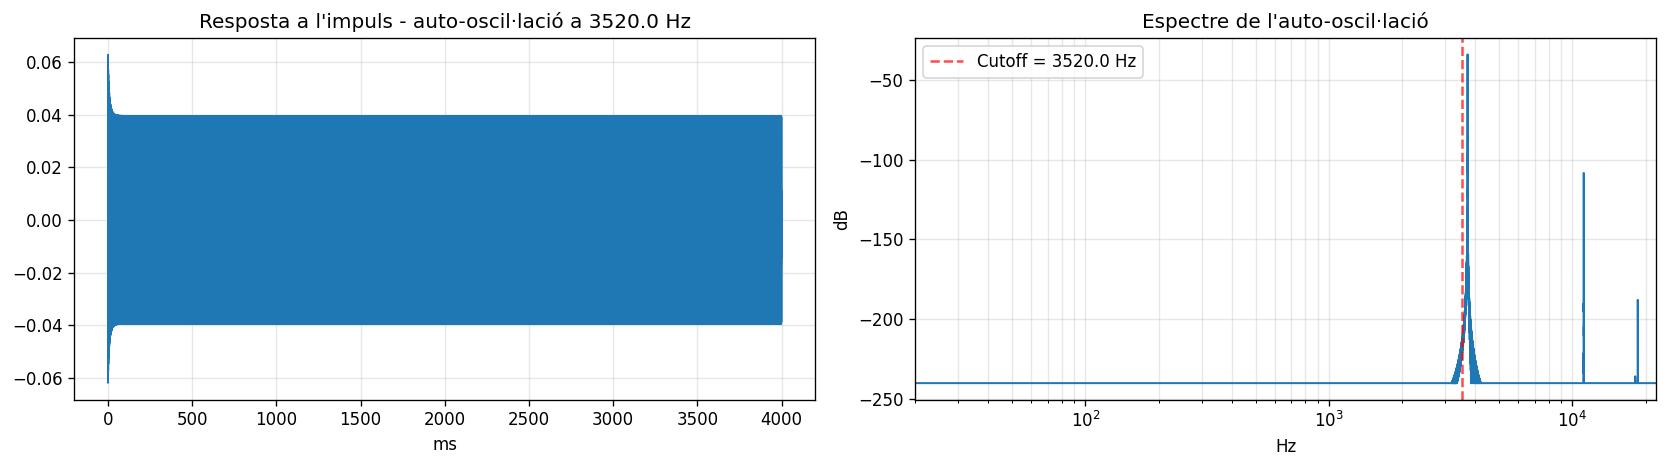

In [18]:
"""
Amb resonance molt propera a 1, el filtre oscil·la.
Es pot excitar amb un impuls breu i després silenci.
"""
SR = 44100
CUTOFF_OSC = 3520.0   # Hz
RES_OSC    = 1.125
DURATION_OSC = 4.0   # s

x_imp = impulse(duration=DURATION_OSC, amplitude=1.0, sr=SR)

filt_osc = MoogLadderFilter(SR, cutoff=CUTOFF_OSC, resonance=RES_OSC, oversample=2)
filt_osc.reset()
y_osc = filt_osc.process(x_imp)

freqs_osc, mag_osc = compute_spectrum(y_osc, SR)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

n_show = len(y_osc)
#n_show = int(SR * 0.05)
t_ms = np.arange(n_show) / SR * 1000
axes[0].plot(t_ms, y_osc[:n_show], lw=0.8)
axes[0].set_title(f"Resposta a l'impuls - auto-oscil·lació a {CUTOFF_OSC} Hz")
axes[0].set_xlabel('ms')
axes[0].grid(alpha=0.3)

axes[1].semilogx(freqs_osc[1:], mag_osc[1:], lw=1.2)
axes[1].axvline(CUTOFF_OSC, color='r', linestyle='--', alpha=0.7,
                label=f'Cutoff = {CUTOFF_OSC} Hz')
axes[1].set_title("Espectre de l'auto-oscil·lació")
axes[1].set_xlabel('Hz')
axes[1].set_ylabel('dB')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)
axes[1].set_xlim([20, SR/2])

plt.tight_layout()
plt.show()

## 6. Prova amb diferents senyals d'entrada

In [ ]:
CUTOFF    = 1500.0
RESONANCE = 1.0
DURATION  = 0.5    # segons
AMPLITUDE = 0.5

signals = {
    'Dent de serra (440 Hz)': sawtooth(440, DURATION, AMPLITUDE, SR),
    'Quadrada (440 Hz)':         square(440,   DURATION, AMPLITUDE, SR),
    'Soroll blanc':              white_noise(DURATION,   AMPLITUDE, SR),
}

fig, axes = plt.subplots(len(signals), 2, figsize=(14, 10))

for row, (name, x) in enumerate(signals.items()):
    filt = MoogLadderFilter(SR, cutoff=CUTOFF, resonance=RESONANCE, oversample=2)
    filt.reset()
    y = filt.process(x)

    freqs_x, mag_x = compute_spectrum(x, SR)
    freqs_y, mag_y = compute_spectrum(y, SR)

    # Forma de onda
    n_show = int(SR * 0.02)
    t_ms   = np.arange(n_show) / SR * 1000
    axes[row, 0].plot(t_ms, x[:n_show], lw=0.8, label='Entrada', alpha=0.7)
    axes[row, 0].plot(t_ms, y[:n_show], lw=0.8, label='Sortida', alpha=0.9)
    axes[row, 0].set_title(f"{name} - forma d'ona (20 ms)")
    axes[row, 0].legend(fontsize=8)
    axes[row, 0].set_xlabel('ms')
    axes[row, 0].grid(alpha=0.3)

    # Espectro
    axes[row, 1].semilogx(freqs_x[1:], mag_x[1:], label='Entrada', alpha=0.7, lw=1)
    axes[row, 1].semilogx(freqs_y[1:], mag_y[1:], label='Sortida', lw=1.3)
    axes[row, 1].axvline(CUTOFF, color='r', linestyle='--', alpha=0.6,
                         label=f'Cutoff {CUTOFF:.0f} Hz')
    axes[row, 1].set_title(f'{name} - espectre')
    axes[row, 1].legend(fontsize=8)
    axes[row, 1].set_xlabel('Hz')
    axes[row, 1].set_ylabel('dB')
    axes[row, 1].grid(True, which='both', alpha=0.3)
    axes[row, 1].set_xlim([20, SR/2])

plt.suptitle(f'Moog Ladder - cutoff={CUTOFF} Hz, resonance={RESONANCE}', fontsize=13)
plt.tight_layout()
plt.show()